In [11]:
import lightkurve
from lightkurve import DesignMatrix, RegressionCorrector
import matplotlib.pyplot as plot
import numpy
%matplotlib inline
plot.style.use('finny_style.mplstyle')

In [12]:
star_id = 427761355
# 306635088
# 375477302
# 734505586
# 467113954
# 11799872
# 451596415
# 295440174
star_id = f'TIC {star_id}'

In [13]:
search_result = lightkurve.search_targetpixelfile(star_id, mission = 'TESS', cadence = 'long')
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 17,2019,TESS-SPOC,1800,427761355,0.0
1,TESS Sector 18,2019,TESS-SPOC,1800,427761355,0.0
2,TESS Sector 57,2022,TESS-SPOC,200,427761355,0.0
3,TESS Sector 58,2022,TESS-SPOC,200,427761355,0.0


In [14]:
pixel_files = search_result.download_all()

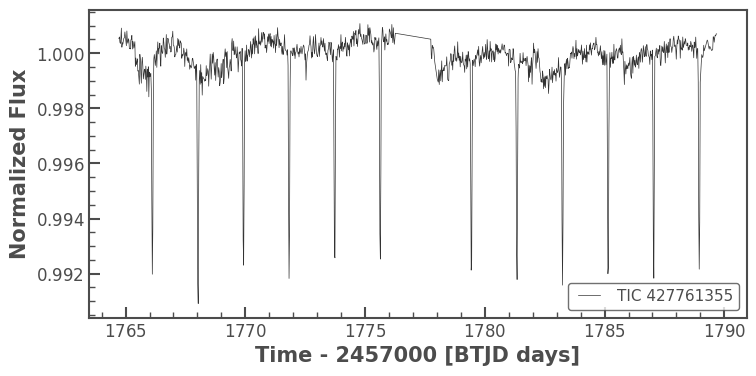

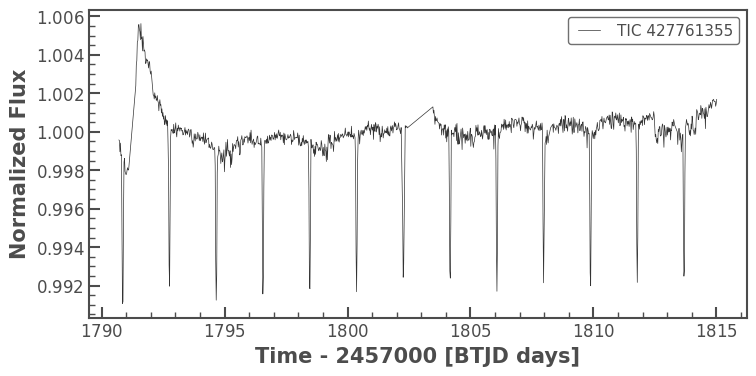

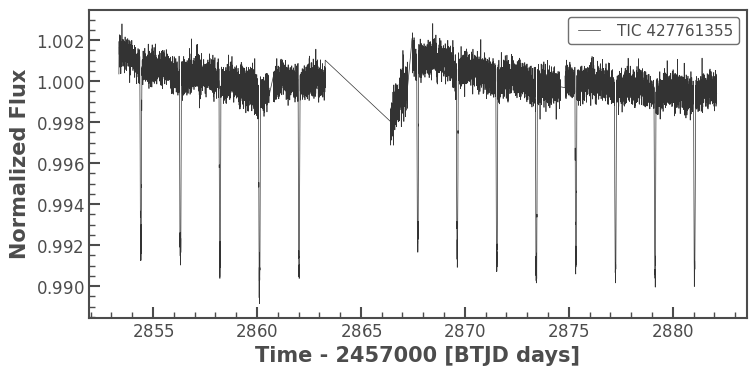

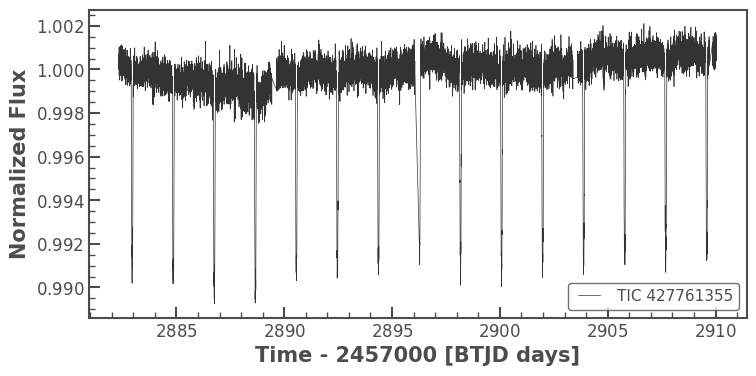

In [15]:
collection = lightkurve.LightCurveCollection(None)
for pixel_file in pixel_files[:]:
    pixel_file = pixel_file[numpy.isfinite(pixel_file.flux).all(axis = (1, 2))]
    pixel_file = pixel_file[numpy.isfinite(pixel_file.flux_err).all(axis = (1, 2))]

    aperture_mask = pixel_file.pipeline_mask
    # aperture_mask = pixel_file.create_threshold_mask(threshold = 10, reference_pixel = 'center')
    uncorrected_lc = pixel_file.to_lightcurve(aperture_mask = aperture_mask)

    # design_matrix = DesignMatrix(pixel_file.flux[:, ~aperture_mask]).pca(5).append_constant()
    # lc = RegressionCorrector(uncorrected_lc).correct(design_matrix)
    lc = uncorrected_lc
    lc = lc.normalize()#.flatten(niters = 10).remove_outliers(10.0)
    lc.plot()
    collection.append(lc)

plot.show()

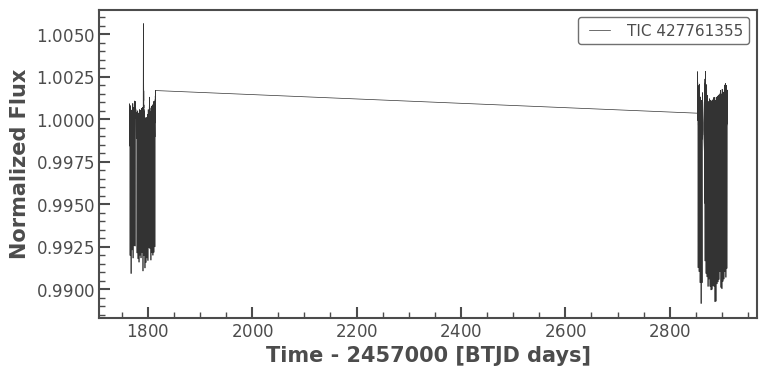

In [16]:
lc = collection[:].stitch()
lc = lc#.flatten(break_tolerance = 10, niters = 10).remove_outliers(sigma = 10.0)
lc.plot()
plot.show()

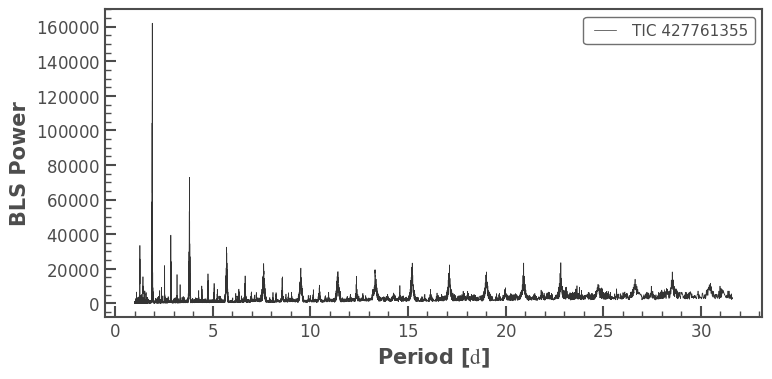

In [17]:
periods = numpy.logspace(0, 1.5, 10 ** 4, base = 10.0)
periodogram = lc.to_periodogram(method = 'boxleastsquares', period = periods, frequency_factor = 10 ** 6)
periodogram.plot()
plot.show()

In [18]:
period = periodogram.period_at_max_power
transit_time = periodogram.transit_time_at_max_power
transit_duration = periodogram.duration_at_max_power
transit_duration = 1

period, transit_time, transit_duration

(<Quantity 1.90251431 d>,
 <Time object: scale='tdb' format='btjd' value=1766.156777196169>,
 1)

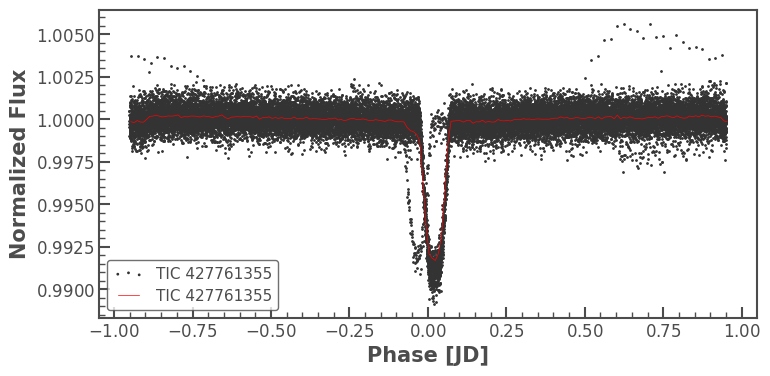

0.008314967155456543

In [19]:
folded_lc = lc.fold(period = period, epoch_time = transit_time)
binned_lc = folded_lc.bin(time_bin_size = 0.01)
ax = folded_lc.scatter()
binned_lc.plot(ax = ax, c = 'r')
d = 1
# ax.set_xlim(-d, d)
# ax.set_ylim(0.995, 1.0025)
plot.show()
1 - numpy.nanmin(binned_lc.flux.value)

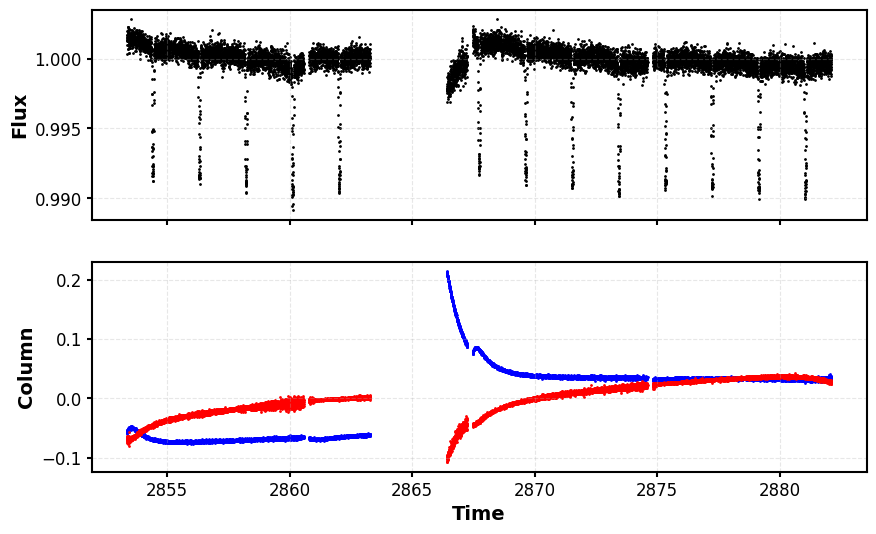

In [25]:
fig, axes = plot.subplots(2, sharex = True)
pixel_file_range = (2, 3)

lc = lightkurve.LightCurveCollection([pixel_file.to_lightcurve() for pixel_file in pixel_files[pixel_file_range[0]:pixel_file_range[1]]]).stitch()
centroids = numpy.concatenate([pixel_file.estimate_centroids() - numpy.nanmean(pixel_file.estimate_centroids(), axis = 1).reshape(-1, 1) for pixel_file in pixel_files[pixel_file_range[0]:pixel_file_range[1]]], axis = 1)

axes[0].scatter(lc.time.value, lc.flux.value, color = 'black', s = 1)
axes[0].set_ylabel('Flux')

axes[1].scatter(lc.time.value, centroids[0], color = 'blue', s = 1)
axes[1].set_ylabel('Row')

axes[1].scatter(lc.time.value, centroids[1], color = 'red', s = 1)
axes[1].set_ylabel('Column')
axes[1].set_xlabel('Time')

plot.show()